In [3]:
# For plotting
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# For logging
from loguru import logger
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Sklearn
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from xgboost import XGBRegressor

DEVICE = 'cuda'

## Importing data

In [4]:
# Saving this data as .csv file to continue with Section 3: Training a machine learning algorithm
filepath = "cleaned_data_ready_for_ml.csv"
df = pd.read_csv(filepath, encoding="utf-8")
logger.info(f"Imported data successfully from {filepath}")

2026-04-27 01:12:02.554 | INFO     | __main__:<module>:4 - Imported data successfully from cleaned_data_ready_for_ml.csv


## Dropping useless columns

In [5]:
## First we drop the Mileage range column because the mileage mean column will encode it's features

## We will also drop the Equipement column because the Number of features directly encodes the usefulness of this column in  a numeric type
df.drop(columns=["Mileage", "Equipment"], inplace=True)
assert "Mileage" not in df.columns and "Equipment" not in df.columns

logger.info("Dropped Mileage and Equipement columns")

2026-04-27 01:12:02.582 | INFO     | __main__:<module>:7 - Dropped Mileage and Equipement columns


In [6]:
## Log-transforming skewed columns (we already log transformed the Price column)
df['Mileage_log'] = np.log1p(df['Mileage_mean'])
## Dropping Mileage_mean as it's log column will encode it's features
df.drop(columns=['Mileage_mean'], inplace=True)
assert "Mileage_mean" not in df.columns.to_list()
logger.info("Dropped Mileage_mean column column")

2026-04-27 01:12:02.607 | INFO     | __main__:<module>:6 - Dropped Mileage_mean column column


## Feature Engineering

In [7]:
# Car age is more intuitive than raw year
df['Age'] = 2025 - df['Year']
df.drop(columns=["Year"], inplace=True)
assert "Year" not in df.columns.to_list()

# Age × Mileage interaction — an old high-mileage car is much worse
df['Age_x_Mileage'] = df['Age'] * df['Mileage_log']

## Metrics calculations

In [8]:
# --- Metrics ---
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"MAE:  {mae:,.0f} MAD")
    print(f"RMSE: {rmse:,.0f} MAD")
    print(f"R²:   {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")

## Training the models
### Training only XGboostRegressor

In [9]:
drop_cols = ['Price', 'Price_log', 'Condition', 'Location', 'Sector', 'NoD']

X = df.drop(columns=drop_cols)
y = df['Price_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_cols = [
    'Age',
    'Fiscal Power',
    'Mileage_log',
    'num_features',
    'condition_numeric',
    'Age_x_Mileage',
    'FO'
]

ohe_cols = ['Gearbox', 'Fuel', 'Origin']
target_enc_cols = ['Brand', 'Model']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), ohe_cols),
        ('target', TargetEncoder(target_type='continuous'), target_enc_cols),
    ]
)


## WE got optimized_params based on running a grid_search
optimized_params = {
    'subsample': 0.7,
    'reg_lambda': 5,
    'reg_alpha': 0,
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.05,
    'colsample_bytree': 0.7,
}

optimized_params.update({
    'device': DEVICE,
    'random_state': 42,

})


xgb_model = XGBRegressor(**optimized_params)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

pipeline.fit(X_train, y_train)
final_xgb_model = pipeline.named_steps['model']


y_pred_log = pipeline.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)
calculate_metrics(y_true, y_pred)

MAE:  14,054 MAD
RMSE: 22,825 MAD
R²:   0.8977
MAPE: 16.78%


c:\Users\PC\Downloads\antigravity.projects\used_cars_dataset\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [01:12:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


## Randomized grid Search Cross validation with 5 fold cross validation for XGBoost


In [10]:
#################### Run Cell on T4 Google colab  ####################
# GPU-optimised RandomizedSearchCV for XGBoost
param_dist = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 1.0],
}
search_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', XGBRegressor(random_state=42, device=DEVICE, tree_method='hist', nthread=1))
])

search = RandomizedSearchCV(search_pipeline, param_dist, n_iter=20, cv=5,
                            scoring='r2', random_state=42, n_jobs=1)
search.fit(X_train, y_train)
print(search.best_params_)


y_log_pred = search.predict(X_test)
true = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)

calculate_metrics(true, y_pred)

{'model__subsample': 0.7, 'model__n_estimators': 500, 'model__max_depth': 6, 'model__learning_rate': 0.05}
MAE:  14,054 MAD
RMSE: 22,825 MAD
R²:   0.8977
MAPE: 16.78%


## Training models:

### Model comparaison:
  - XGboost
  - Linear regression
  - Linear regression Lasso
  - Linear regression Ridge
  - Random Forest

In [11]:
# Compare 4 models using the same preprocessing pipeline
results = {}

optimized_params_rf = {
    'n_estimators': 300,
     'max_depth': 20,
     'min_samples_split': 2,
     'min_samples_leaf': 1,
     'max_features': 'log2',
     'bootstrap': False
}

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=0.1),
    "Lasso": Lasso(alpha=0.1, max_iter=10_000),
    "XGBoost": XGBRegressor(
        **{
            **optimized_params,
            "device": DEVICE,   # safer for notebooks; change to "cuda" if your GPU setup works
            "random_state": 42,
            "objective": "reg:squarederror",
        }
    ),
    "Random Forest": RandomForestRegressor(**optimized_params_rf)

}
## RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

for name, model in models.items():
    model_pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", model),
    ])

    model_pipeline.fit(X_train, y_train)

    preds_log = model_pipeline.predict(X_test)

    # Convert log prices back to real MAD prices
    preds = np.expm1(preds_log)
    true = np.expm1(y_test)

    results[name] = {
        "R²": r2_score(true, preds),
        "MAE": mean_absolute_error(true, preds),
        "RMSE": np.sqrt(mean_squared_error(true, preds)),
        "MAPE": np.mean(np.abs((true - preds) / true)) * 100,
    }

    print(
        f"{name:20s} → "
        f"R²: {results[name]['R²']:.4f}  "
        f"MAPE: {results[name]['MAPE']:.2f}%  "
        f"RMSE: {results[name]['RMSE']:,.0f} MAD  "
        f"MAE: {results[name]['MAE']:,.0f} MAD"
    )


Linear Regression    → R²: 0.8027  MAPE: 22.55%  RMSE: 31,697 MAD  MAE: 20,510 MAD
Ridge                → R²: 0.8028  MAPE: 22.55%  RMSE: 31,692 MAD  MAE: 20,510 MAD
Lasso                → R²: 0.5538  MAPE: 32.48%  RMSE: 47,670 MAD  MAE: 31,530 MAD
XGBoost              → R²: 0.9031  MAPE: 16.40%  RMSE: 22,212 MAD  MAE: 13,618 MAD
Random Forest        → R²: 0.9114  MAPE: 14.94%  RMSE: 21,237 MAD  MAE: 12,146 MAD


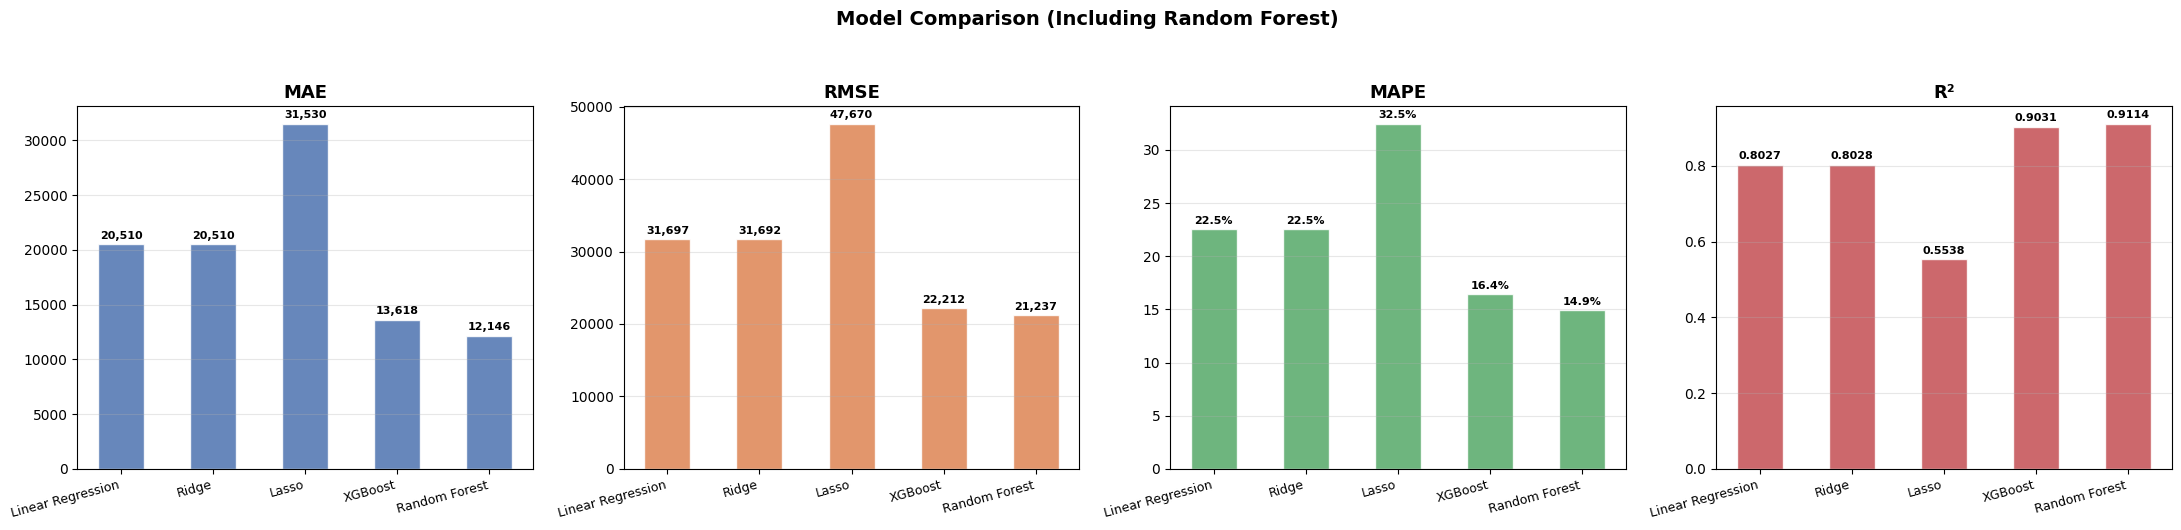

In [12]:
# Re-generate the comparison plot with Random Forest included
models_list = list(results.keys())
metrics = ["MAE", "RMSE", "MAPE", "R²"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
x = np.arange(len(models_list))

for ax, metric, color in zip(axes, metrics, colors):
    values = [results[m][metric] for m in models_list]
    bars = ax.bar(x, values, width=0.5, color=color, alpha=0.85, edgecolor="white")

    for bar, val in zip(bars, values):
        if metric == "MAPE":
            label = f"{val:.1f}%"
        elif metric == "R²":
            label = f"{val:.4f}"
        else:
            label = f"{val:,.0f}"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.01, label, ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=15, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Model Comparison (Including Random Forest)", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

### 4. Feature Importance
Analyzing which features contribute most to the model's decisions.

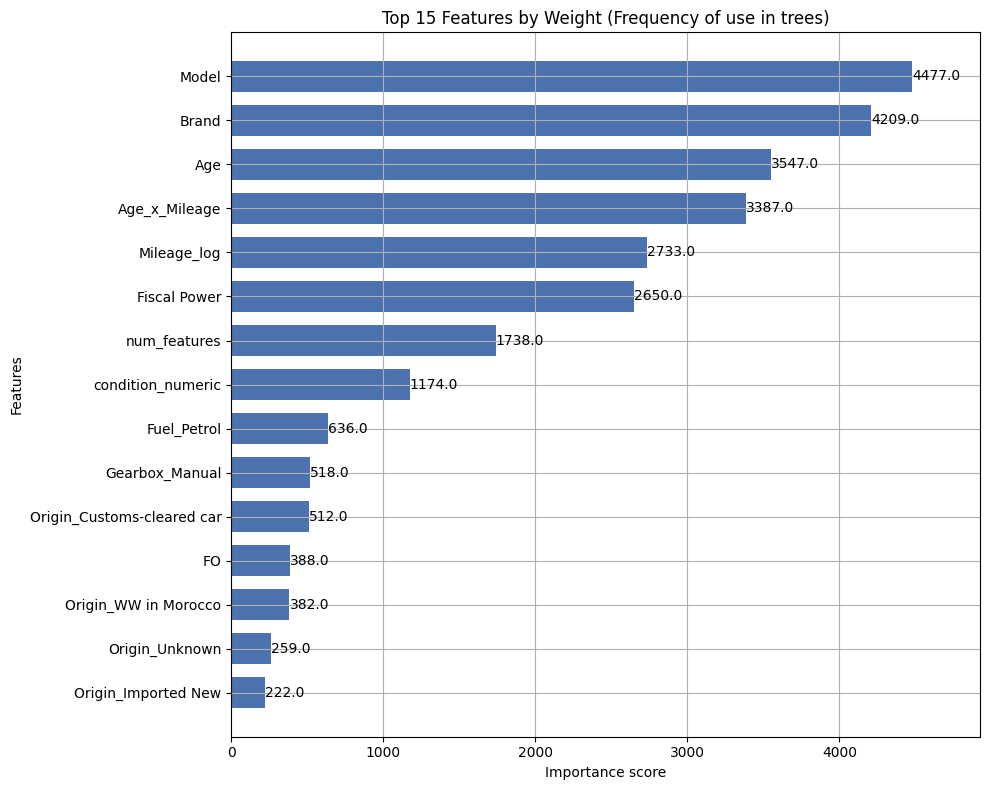

In [13]:
import xgboost as xgb

# 1. Extract the trained XGBoost model from the pipeline
final_xgb_model = pipeline.named_steps['model']

# # 2. Get feature names after preprocessing
# # This handles the transformation of columns (One-Hot Encoding, etc.)
ohe_feature_names = pipeline.named_steps['preprocessor']\
     .named_transformers_['ohe']\
     .get_feature_names_out(ohe_cols).tolist()

all_features = numeric_cols + ohe_feature_names + target_enc_cols

# 3. Plot Feature Importance
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(final_xgb_model, ax=ax, importance_type='weight',
                   max_num_features=15, height=0.7, color='#4C72B0')

# Fix the labels because XGBoost uses f0, f1... by default when passed raw arrays
# We map them back to our feature list
ticks = ax.get_yticklabels()
labels = [all_features[int(t.get_text()[1:])] if t.get_text().startswith('f') else t.get_text() for t in ticks]
ax.set_yticklabels(labels)

plt.title('Top 15 Features by Weight (Frequency of use in trees)')
plt.tight_layout()
plt.show()